## Resampling Techniques — Lab 2
### 202303061- Virat Shrimali

##Problem 3(a) - Constructing Uniform(0, θ) using only randint()

### Problem Statement

We are given access only to:

    random.randint(a, b)

which generates a discrete uniform integer between a and b.

Our task is to construct a random variable:

    U ~ Uniform(0, θ)

accurate up to **5 decimal places**, using only `randint()`.


### Methodology

#### Step 1: Construct Uniform(0,1) up to 5 decimal places

If we generate:

    K ~ Uniform{0,1,2,...,99999}

then define:

    U = K / 100000

This produces values:

    {0, 0.00001, 0.00002, ..., 0.99999}

Thus U approximates a continuous Uniform(0,1)
with precision up to 5 decimal places.

---

#### Step 2: Scale to Uniform(0, θ)

If:

    U ~ Uniform(0,1)

then:

    X = θU

satisfies:

    X ~ Uniform(0, θ)

---

### Final Algorithm

1. Generate K = randint(0, 99999)
2. Compute U = K / 100000
3. Return X = θU


In [ ]:
import random

def uniform_0_theta(theta):
    """
    Generates X ~ Uniform(0, theta)
    accurate up to 5 decimal places,
    using only randint().
    """

    # Step 1: Generate integer in {0,...,99999}
    k = random.randint(0, 99999)

    # Step 2: Convert to Uniform(0,1)
    u = k / 100000

    # Step 3: Scale to (0, theta)
    return theta * u


### Verification

We generate multiple samples and check:

- Values lie between 0 and θ
- Precision is up to 5 decimal places


In [ ]:
theta = 5

samples = [uniform_0_theta(theta) for _ in range(10)]
samples


[3.5507,
 0.71665,
 0.4918,
 0.33594999999999997,
 0.0499,
 2.4228,
 3.234,
 1.00745,
 1.9172500000000001,
 3.0536000000000003]

### Empirical Validation

For a Uniform(0, θ) random variable:

    E[X] = θ / 2

We simulate many samples and compute the sample mean.
If the generator is correct, the empirical mean should be close to θ/2.


In [ ]:
import numpy as np

theta = 5
N = 100000

samples = np.array([uniform_0_theta(theta) for _ in range(N)])

print("Sample mean:", samples.mean())
print("Theoretical mean:", theta / 2)


Sample mean: 2.4999461960000002
Theoretical mean: 2.5


## Part 3(b): Inverse Transform Method

If U ~ Uniform(0,1) and X = F^{-1}(U),
then X has distribution function F.

For Exponential(θ):

    F(x) = 1 - exp(-x/θ),  x ≥ 0

Solve U = F(x):

    U = 1 - exp(-x/θ)

    exp(-x/θ) = 1 - U

    x = -θ ln(1 - U)

Thus we generate:

    X = -θ ln(U)

which follows Exponential(θ).


In [ ]:
import math

def uniform_0_1():
    """
    Generates U ~ Uniform(0,1)
    accurate up to 5 decimal places
    using only randint().
    """
    k = random.randint(1, 99999)  # avoid zero (log(0) undefined)
    return k / 100000


def exponential_theta(theta):
    """
    Generates X ~ Exponential(theta)
    using inverse transform method.
    """
    u = uniform_0_1()
    return -theta * math.log(u)


In [ ]:
theta = 2
samples = [exponential_theta(theta) for _ in range(10)]
samples


[0.5049902500581371,
 2.48244958005765,
 0.8000299740727704,
 0.6472265373400894,
 0.6865587051083809,
 2.7831766991620004,
 0.8734162556961925,
 0.40315554679929827,
 2.3336109599689934,
 5.287617198081491]

### Interpretation

The generated values are random samples from the
Exponential(θ) distribution obtained using the inverse transform method.

Each value is non-negative and follows:

    X = -θ ln(U),  where U ~ Uniform(0,1).


### Empirical Validation

For an Exponential(θ) random variable:

    E[X] = θ

We generate a large number of samples and compute the sample mean.
If the implementation is correct, the empirical mean should be close to θ.


In [ ]:
import numpy as np

theta = 2
N = 100000

samples = np.array([exponential_theta(theta) for _ in range(N)])

print("Sample mean:", samples.mean())
print("Theoretical mean:", theta)


Sample mean: 1.994041430128038
Theoretical mean: 2


## Part 3(c): Box–Muller Transformation

If U1, U2 ~ Uniform(0,1) independently, define:

    Z1 = sqrt(-2 ln U1) cos(2π U2)
    Z2 = sqrt(-2 ln U1) sin(2π U2)

Then:

    Z1, Z2 ~ N(0,1)

Thus, using two independent Uniform(0,1) random variables,
we can generate two independent standard normal random variables.


In [ ]:
import math

def uniform_0_1():
    """
    Generates U ~ Uniform(0,1)
    accurate up to 5 decimal places.
    """
    k = random.randint(1, 99999)  # avoid 0
    return k / 100000


def box_muller():
    """
    Generates two independent N(0,1) random variables
    using the Box–Muller transformation.
    """
    u1 = uniform_0_1()
    u2 = uniform_0_1()

    z1 = math.sqrt(-2 * math.log(u1)) * math.cos(2 * math.pi * u2)
    z2 = math.sqrt(-2 * math.log(u1)) * math.sin(2 * math.pi * u2)

    return z1, z2


### Quick Test

We generate a few samples to verify:

- Values appear centered around 0
- Both positive and negative values occur


In [ ]:
samples = [box_muller()[0] for _ in range(10)]
samples


[0.02955693485493039,
 -0.3239765863735684,
 -0.2565555714408367,
 1.0583985725491132,
 -0.852108542463788,
 -0.16892759067223287,
 -1.407548386192811,
 1.3108951264995814,
 -0.15186253774596836,
 -0.2504057947114962]

### Empirical Validation

For a standard normal random variable Z ~ N(0,1):

    E[Z] = 0
    Var(Z) = 1

We generate a large number of samples using the Box–Muller transformation
and compute the sample mean and variance.

If the implementation is correct, the empirical mean should be close to 0
and the empirical variance should be close to 1.


In [ ]:
import numpy as np

N = 100000
samples = []

# N//2 (integer division) because each call gives 2 normals, for N normals we
# run it for N//2 times
for _ in range(N // 2):
    z1, z2 = box_muller()  #produces two independent N(0,1) variables.
    samples.append(z1)
    samples.append(z2)

samples = np.array(samples)

print("Sample mean:", samples.mean())
print("Sample variance:", samples.var())


Sample mean: 0.004700759692716913
Sample variance: 0.9959593631005793


## Part 3(d): Correlated Bivariate Normal

Let Z1, Z2 ~ N(0,1) be independent.

Define:

    X = Z1
    Y = ρZ1 + sqrt(1 - ρ²) Z2

Then:

    E[X] = E[Y] = 0
    Var(X) = Var(Y) = 1
    Corr(X,Y) = ρ

Thus (X,Y) follows a bivariate normal distribution with
mean vector (0,0) and covariance matrix:

        [ 1   ρ ]
        [ ρ   1 ]


In [ ]:
def correlated_bivariate_normal(rho):
    """
    Generates one sample (X, Y)
    from a bivariate normal distribution
    with correlation rho.
    """
    z1, z2 = box_muller()

    x = z1
    y = rho * z1 + math.sqrt(1 - rho**2) * z2

    return x, y


### Empirical Verification

We generate many samples and compute the empirical correlation.

If the implementation is correct, the sample correlation
should be close to the chosen value of ρ.


In [15]:
import numpy as np

rho = 0.7
N = 100000

X = []
Y = []

for _ in range(N // 2):
    x1, y1 = correlated_bivariate_normal(rho)
    X.append(x1)
    Y.append(y1)

    x2, y2 = correlated_bivariate_normal(rho)
    X.append(x2)
    Y.append(y2)

X = np.array(X)
Y = np.array(Y)

print("Empirical correlation:", np.corrcoef(X, Y)[0,1])
print("Target correlation:", rho)


Empirical correlation: 0.6997229689378748
Target correlation: 0.7


## Problem 4: Sampling Distribution of Covariance

We simulate the sampling distribution of the sample covariance
for a bivariate normal distribution with correlation ρ.

Theoretical results:

    Bias(ρ̂) = -ρ / n

    Var(ρ̂) = (1/n)(1 + ρ²) - (2ρ²)/n

We compare:

- Theoretical bias and variance
- Empirical estimates (from simulations)
- Jackknife estimates (from one sample)


In [16]:
def generate_sample(n, rho):
    X = []
    Y = []

    for _ in range(n):
        x, y = correlated_bivariate_normal(rho)
        X.append(x)
        Y.append(y)

    return np.array(X), np.array(Y)


In [17]:
def sample_covariance(X, Y):
    n = len(X)
    return np.sum((X - X.mean()) * (Y - Y.mean())) / n


In [18]:
def simulate_sampling_distribution(n, rho, repetitions=1000):
    estimates = []

    for _ in range(repetitions):
        X, Y = generate_sample(n, rho)
        estimates.append(sample_covariance(X, Y))

    return np.array(estimates)


In [19]:
def empirical_bias_variance(estimates, rho):
    bias = estimates.mean() - rho
    variance = estimates.var()
    return bias, variance


In [20]:
def jackknife_covariance(X, Y):
    n = len(X)
    jack_estimates = []

    for i in range(n):
        X_j = np.delete(X, i)
        Y_j = np.delete(Y, i)
        jack_estimates.append(sample_covariance(X_j, Y_j))

    jack_estimates = np.array(jack_estimates)

    jack_mean = jack_estimates.mean()
    original = sample_covariance(X, Y)

    # Jackknife bias estimate
    bias_jack = (n - 1) * (jack_mean - original)

    # Jackknife variance
    var_jack = (n - 1) * np.mean((jack_estimates - jack_mean)**2)

    return bias_jack, var_jack


In [21]:
rhos = [0, 0.3, 0.7]
ns = [10, 30, 100]

for rho in rhos:
    for n in ns:
        estimates = simulate_sampling_distribution(n, rho)
        bias_emp, var_emp = empirical_bias_variance(estimates, rho)

        # one sample for jackknife
        X, Y = generate_sample(n, rho)
        bias_jack, var_jack = jackknife_covariance(X, Y)

        print(f"rho={rho}, n={n}")
        print("Empirical Bias:", bias_emp)
        print("Empirical Variance:", var_emp)
        print("Jackknife Bias:", bias_jack)
        print("Jackknife Variance:", var_jack)
        print()


rho=0, n=10
Empirical Bias: 0.002282070183692169
Empirical Variance: 0.08209290611428957
Jackknife Bias: 0.00889636628473954
Jackknife Variance: 0.09605703279319053

rho=0, n=30
Empirical Bias: -0.004406873459171997
Empirical Variance: 0.0330059096290109
Jackknife Bias: -0.003134104464207102
Jackknife Variance: 0.02590234870516398

rho=0, n=100
Empirical Bias: 0.0010755920053839762
Empirical Variance: 0.009955400710911621
Jackknife Bias: 0.00032447966925126803
Jackknife Variance: 0.007210240749135168

rho=0.3, n=10
Empirical Bias: -0.03474386789450762
Empirical Variance: 0.10259572046811419
Jackknife Bias: -0.049065058986463406
Jackknife Variance: 0.03678917662946507

rho=0.3, n=30
Empirical Bias: -0.012288971514122171
Empirical Variance: 0.03731243669595844
Jackknife Bias: -0.03048261652064932
Jackknife Variance: 0.05943290139719468

rho=0.3, n=100
Empirical Bias: -0.0002389289712447229
Empirical Variance: 0.010702349368550298
Jackknife Bias: -0.004629290494992111
Jackknife Variance: 

### Jackknife Bias Estimation

From a single sample of size $n$, we compute leave-one-out estimates:

$$
\hat{\rho}_{(i)}
$$

The jackknife bias estimate is:

$$
\widehat{\text{Bias}}_{jack}
=
(n-1)\left(\overline{\hat{\rho}_{(i)}} - \hat{\rho}\right)
$$

This approximates the theoretical bias:
$$
\text{Bias}(\hat{\rho}) = -\frac{\rho}{n}.
$$

### Jackknife Bias Correction

The bias-corrected estimator is:

$$
\hat{\rho}_{bc}
=
\hat{\rho}
-
\widehat{\text{Bias}}_{jack}
$$

Since the bias is of order $1/n$, correction is more important
for small sample sizes.


### Comparison Before and After Correction

We compare:

- Original bias:  $\hat{\rho} - \rho$
- Corrected bias:  $\hat{\rho}_{bc} - \rho$

For small $n$, bias correction reduces systematic error.
For large $n$, bias is already small, so the correction has limited impact.


In [22]:
def jackknife_bias_correction(X, Y):
    n = len(X)

    # Original estimate
    original = sample_covariance(X, Y)

    jack_estimates = []

    for i in range(n):
        X_j = np.delete(X, i)
        Y_j = np.delete(Y, i)
        jack_estimates.append(sample_covariance(X_j, Y_j))

    jack_estimates = np.array(jack_estimates)
    jack_mean = jack_estimates.mean()

    # Jackknife bias estimate
    bias_jack = (n - 1) * (jack_mean - original)

    # Bias corrected estimator
    corrected = original - bias_jack

    return original, bias_jack, corrected


In [23]:
rho = 0.7
n = 30

X, Y = generate_sample(n, rho)

original, bias_jack, corrected = jackknife_bias_correction(X, Y)

print("Original estimate:", original)
print("Jackknife bias estimate:", bias_jack)
print("Bias-corrected estimate:", corrected)


Original estimate: 0.8077154080758704
Jackknife bias estimate: -0.02785225545088843
Bias-corrected estimate: 0.8355676635267588


### Final Interpretation

1. The sample covariance has theoretical bias:
$
\text{Bias}(\hat{\rho}) = -\frac{\rho}{n}
$
and variance of order $1/n$, so both bias and variability decrease as $n$ increases.

2. Empirical bias and variance (from 1000 simulations) are close to theoretical values due to repeated independent sampling.

3. Jackknife estimates are computed from a single sample using leave-one-out values:
$$
\widehat{\text{Bias}}_{jack} = (n-1)(\overline{\hat{\rho}_{(i)}} - \hat{\rho})
$$
They may be noisier but approximate the true bias reasonably well.

4. Bias correction:
$$
\hat{\rho}_{bc} = \hat{\rho} - \widehat{\text{Bias}}_{jack}
$$
reduces bias, especially for small $n$.

Because the bias shrinks at rate
1
/
𝑛
:

    For small 𝑛 → bias is relatively large → correction helps.

    For large 𝑛 → bias is already tiny → correction has little effect.

5. Computation time: simulation (1000 samples) is more expensive, while jackknife is faster but still $O(n^2)$.


## Problem 5: Bias–Variance Tradeoff for Uniform(0, θ)

Let:

$$
X_1, \dots, X_n \sim \text{Uniform}(0, \theta)
$$

The parameter of interest is:

$$
\theta
$$

We compare three estimators of θ and evaluate them using:

$$
\text{MSE}(\hat{\theta}) = \text{Bias}(\hat{\theta})^2 + \text{Var}(\hat{\theta})
$$


### Simulation Setup

We fix:

$$
\theta = 1
$$

For each sample size:

$$
n \in \{5, 10, 20, 50, 100\}
$$

we simulate the three estimators:

1. Maximum estimator  
   $$
   \hat{\theta}_{max} = X_{(n)}
   $$

2. Range estimator  
   $$
   \hat{\theta}_{range}
   =
   \frac{n+1}{n-1}(X_{(n)} - X_{(1)})
   $$

3. Jackknife bias-corrected estimator  
   $$
   \hat{\theta}_{jack}^{(bc)}
   =
   \frac{2n-1}{n}X_{(n)}
   -
   \frac{n-1}{n}X_{(n-1)}
   $$


In [24]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_estimators(n, theta=1, repetitions=10000):

    theta_max = []
    theta_range = []
    theta_jack = []

    for _ in range(repetitions):
        X = np.random.uniform(0, theta, n)
        X_sorted = np.sort(X)

        # Maximum estimator
        theta_max.append(X_sorted[-1])

        # Range estimator
        theta_range.append((n+1)/(n-1) * (X_sorted[-1] - X_sorted[0]))

        # Jackknife corrected
        theta_jack.append(
            ((2*n - 1)/n)*X_sorted[-1] - ((n - 1)/n)*X_sorted[-2]
        )

    return np.array(theta_max), np.array(theta_range), np.array(theta_jack)


### Performance Metrics

For an estimator $\hat{\theta}$:

$$
\text{Bias}(\hat{\theta}) = \mathbb{E}[\hat{\theta}] - \theta
$$

$$
\text{Var}(\hat{\theta}) = \mathbb{E}\left[(\hat{\theta} - \mathbb{E}[\hat{\theta}])^2\right]
$$

$$
\text{MSE}(\hat{\theta}) = \text{Bias}(\hat{\theta})^2 + \text{Var}(\hat{\theta})
$$

We estimate these quantities using repeated simulation.


In [25]:
def compute_metrics(estimates, theta=1):
    bias = estimates.mean() - theta
    variance = estimates.var()
    mse = bias**2 + variance
    return bias, variance, mse


### Simulation Across Sample Sizes

For each value of $n$, we generate many independent samples
and compute empirical:

- Bias
- Variance
- MSE

This approximates the true sampling performance of each estimator.


In [26]:
theta = 1
ns = [5, 10, 20, 50, 100]

results = {}

for n in ns:
    max_est, range_est, jack_est = simulate_estimators(n, theta)

    results[n] = {
        "max": compute_metrics(max_est, theta),
        "range": compute_metrics(range_est, theta),
        "jack": compute_metrics(jack_est, theta)
    }


### MSE Comparison

We plot:

$$
\text{MSE} \quad \text{vs} \quad n
$$

to compare estimator performance.

The estimator with the smallest MSE is preferred.


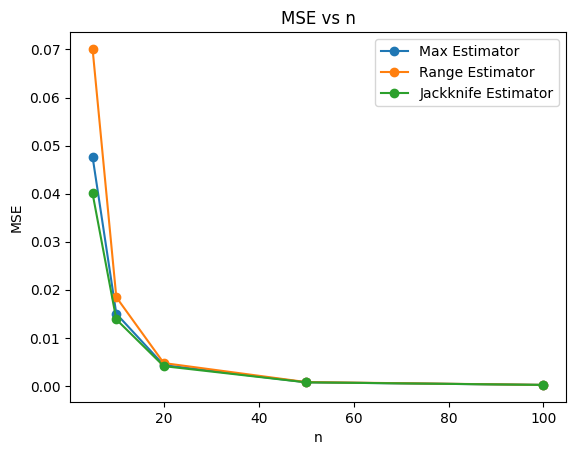

In [27]:
mse_max = []
mse_range = []
mse_jack = []

for n in ns:
    mse_max.append(results[n]["max"][2])
    mse_range.append(results[n]["range"][2])
    mse_jack.append(results[n]["jack"][2])

plt.plot(ns, mse_max, marker='o', label='Max Estimator')
plt.plot(ns, mse_range, marker='o', label='Range Estimator')
plt.plot(ns, mse_jack, marker='o', label='Jackknife Estimator')

plt.xlabel("n")
plt.ylabel("MSE")
plt.legend()
plt.title("MSE vs n")
plt.show()


### Interpretation with Mathematical Justification

For $X_1,\dots,X_n \sim \text{Uniform}(0,\theta)$:

$$
\mathbb{E}[X_{(n)}] = \frac{n}{n+1}\theta,
\quad
\text{Bias}_{max} = -\frac{\theta}{n+1}.
$$

$$
\text{Var}(X_{(n)}) =
\frac{n\theta^2}{(n+1)^2(n+2)}.
$$

---

### Why Does Bias Correction Improve MSE for Small $n$?

$$
\text{MSE} = \text{Bias}^2 + \text{Var}.
$$

For the maximum estimator:

$$
\text{Bias}^2 = \frac{\theta^2}{(n+1)^2},
\quad
\text{Var} = \frac{n\theta^2}{(n+1)^2(n+2)}.
$$

For small $n$, $\text{Bias}^2$ is often larger than $\text{Var}$,
so reducing bias significantly lowers MSE.

The jackknife estimator reduces bias from order $1/n$ to order $1/n^2$,
thus substantially reducing $\text{Bias}^2$ when $n$ is small.

---

### Why Does Variance Decrease with $n$?

$$
\text{Var}(X_{(n)}) \sim \frac{\theta^2}{n^2}.
$$

As $n$ increases, the maximum concentrates near $\theta$,
so variability decreases.

---

### Why Does $\text{MSE} \to 0$ as $n \to \infty$?

Since both:

$$
\text{Bias}^2 \sim \frac{1}{n^2},
\quad
\text{Var} \sim \frac{1}{n^2},
$$

we obtain:

$$
\text{MSE} \to 0.
$$

Thus all estimators are consistent.

---

### Why Do Estimator Differences Diminish for Large $n$?

As $n \to \infty$:

$$
\frac{1}{n} \to 0,
\quad
\frac{1}{n^2} \to 0.
$$

Hence bias differences between estimators become negligible,
and their MSE values converge.

---

### Why Can an Unbiased Estimator Have Larger MSE?

Because:

$$
\text{MSE} = \text{Bias}^2 + \text{Var}.
$$

An estimator with zero bias but large variance
can have larger MSE than a slightly biased estimator
with much smaller variance.
